**Table of contents**<a id='toc0_'></a>    
- [Modeling](#toc1_)    
  - [Explanation](#toc1_1_)    
    - [PFA and delta-photon-arrival-time distribution](#toc1_1_1_)    
    - [Need of marginal distribution](#toc1_1_2_)    
    - [Incooperation of not observed events](#toc1_1_3_)    
    - [The z parameter](#toc1_1_4_)    
    - [Fitting performance](#toc1_1_5_)    
    - [Use of binned data](#toc1_1_6_)    
  - [ Parameter table](#toc1_2_)    
  - [Figures](#toc1_3_)    
    - [Figure 1](#toc1_3_1_)    
      - [Preparing 3F plot](#toc1_3_1_1_)    
      - [Preparing 2F plot](#toc1_3_1_2_)    
      - [Plot](#toc1_3_1_3_)    
    - [Figure 2](#toc1_3_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Modeling](#toc0_)

In [1]:
import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams

import fluopy.distributions as dist
import fluopy.figure as fi

saving_at = r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_5_modeling"

## <a id='toc1_1_'></a>[Explanation](#toc0_)

### <a id='toc1_1_1_'></a>[PFA and delta-photon-arrival-time distribution](#toc0_)
The model to describe PFA may require a lot of parameters depending on the number of fluorophores. Hence, it has too many degrees of freedom to accurately and deterministically predict a set of parameters. Therefore, not only the PFA fit but also the individual delta-photon-arrival-times (sets of photons between photobleaching events) are also used - their parameters are directly used for the PFA model. 
### <a id='toc1_1_2_'></a>[Need of marginal distribution](#toc0_)
However, since the data to be fit comes from multiple simulation runs and each run produces different photobleaching times, the acquired data represents differently truncated distributions. In order to make the target distribution incooperate the variable truncation point, the marginal distribution is used to describe the delta-photon-arrival-times. An exception is the first set, which is always truncated at the same point.\
Note: for some datasets, only a few truncation points (preceding photobleaching events) are available. Hence, describing those truncation points with a distribution is less accurate. 
### <a id='toc1_1_3_'></a>[Incooperation of not observed events](#toc0_)
Since simulations also allow for knowledge of the number of not observed events, those are used in the fits aswell.
### <a id='toc1_1_4_'></a>[The z parameter](#toc0_)
z determines the index of delta-photon-arrival-times that will be described with a three-exp-mix-distr instead of a two-exp-mix-distr. Assuming a completely symmetrical fluorophore configuration (such that whenever a fluorophore photobleaches, only 1 possible configuration is left), z_n must be z_(n+1) - 1 when fitting the delta-photon-arrival-times of the n-fluorophore configuration. z = -1 means no three_exp-mix-distr. \
Here, 3nm 4F z = 2, 6nm 4F z = 0, 9nm 4F z = -1, 18nm 4F z = -1
### <a id='toc1_1_5_'></a>[Fitting performance](#toc0_)
The distributions are monitored using CDFs on linear scales and PDFs on logarithmic scales. The fits may look worse for larger distances and smaller number of fluorophores left. Some reasons are:
- less photons (less accurate)
- less variable truncation points (i.e., the variable truncation points are modelled using a distribution, which may not be representative for a small sample)
- variable truncation points more important, which are modelled using parts of PFA model - subsequent errors
- general assumptions listed for the model derivation may not hold as much
### <a id='toc1_1_6_'></a>[Use of binned data](#toc0_)
The log-likelihood functions expect binned data as input. This is done because it doesn't need as much memory and is still sensitive if combined with log bins.

## <a id='toc1_2_'></a>[ Parameter table](#toc0_)

In [23]:
parameters_2F_3nm = np.load(
    r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_5_modeling\2F\3nm\parameters_2F_3nm.npy"
)
parameters_2F_3nm_copy = parameters_2F_3nm.copy()
parameters_2F_3nm_copy[0] += 2
parameters_3F_3nm = np.load(
    r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_5_modeling\3F\3nm\parameters_3F_3nm.npy"
)
parameters_3F_3nm_copy = parameters_3F_3nm.copy()
parameters_3F_3nm_copy[0] += 1
parameters_4F_3nm = np.load(
    r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_5_modeling\4F\3nm\parameters_4F_3nm.npy"
)

In [24]:
subcols = {
    0: [r"$p_{b|1}$", r"$p_{nb|1}$", r"$\lambda_{b|1}$", r"$\lambda_{nb|1}$"],
    1: [r"$p_{b|2}$", r"$p_{nb|2}$", r"$\lambda_{b|2}$", r"$\lambda_{nb|2}$"],
    2: [
        r"$p_{b|3}$",
        r"$p_{nb_{1}|3}$",
        r"$p_{nb_{2}|3}$",
        r"$\lambda_{b|3}$",
        r"$\lambda_{nb_{1}|3}$",
        r"$\lambda_{nb_{2}|3}$",
    ],
    3: [r"$p_{b|4}$", r"$p_{nb|4}$", r"$\lambda_{b|4}$", r"$\lambda_{nb|4}$"],
}
flat_cols = [lbl for labels in subcols.values() for lbl in labels]

In [25]:
def array_to_series(arr, subcols, flat_cols):
    data = {}
    counters = {idx: 0 for idx in arr[0]}
    for idx, val in zip(arr[0], arr[1]):
        lbl = subcols[idx][counters[idx]]
        data[lbl] = val
        counters[idx] += 1
    return pd.Series(data, index=flat_cols, dtype=float)


df = pd.DataFrame(
    [
        array_to_series(parameters_2F_3nm_copy, subcols, flat_cols),
        array_to_series(parameters_3F_3nm_copy, subcols, flat_cols),
        array_to_series(parameters_4F_3nm, subcols, flat_cols),
    ],
    index=["2F", "3F", "4F"],
)

<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
C:\Users\vie43sq\AppData\Local\Temp\ipykernel_12488\2324900467.py:23: SyntaxWarning: invalid escape sequence '\p'
  plt.savefig(saving_at + '\parameter_table.png', dpi=300)
C:\Users\vie43sq\AppData\Local\Temp\ipykernel_12488\2324900467.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cell_text = df.applymap(sci_fmt).values


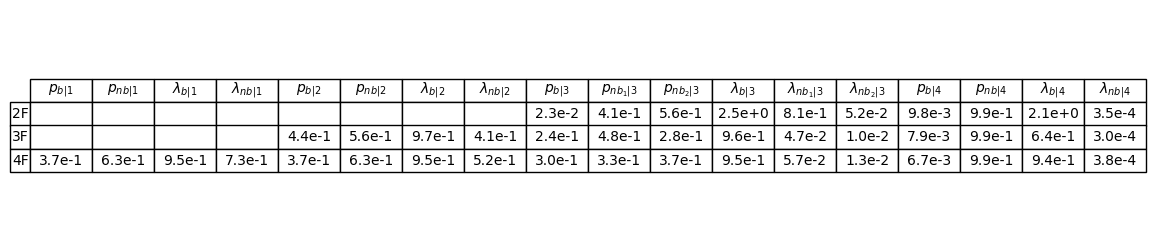

In [ ]:
def sci_fmt(x, prec=1):
    if pd.isna(x):
        return ""
    return f"{x:.{prec}e}".replace("e-0", "e-").replace("e+0", "e+")


fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")
cell_text = df.applymap(sci_fmt).values
col_labels = df.columns.tolist()

table = ax.table(
    cellText=cell_text,
    rowLabels=df.index,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.4)

plt.savefig(saving_at + r"\parameter_table.png", dpi=300)

## <a id='toc1_3_'></a>[Figures](#toc0_)

In [27]:
rcParams["axes.linewidth"] = 2
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

### <a id='toc1_3_1_'></a>[Figure 1](#toc0_)

#### <a id='toc1_3_1_1_'></a>[Preparing 3F plot](#toc0_)

In [28]:
uniq, inv = np.unique(parameters_3F_3nm[0], return_inverse=True)
parameter_dict_pfa = {
    int(u): list(parameters_3F_3nm[1][inv == i]) for i, u in enumerate(uniq)
}
cdf_3F = dist.Photoswitching_fingerprint_model(parameter_dict_pfa, None, (0, 300)).cdf

In [29]:
uniq, inv = np.unique(parameters_4F_3nm[0], return_inverse=True)
parameter_dict_pfa_2 = {
    int(u - 1): list(parameters_4F_3nm[1][inv == i])
    for i, u in enumerate(uniq)
    if i != 0
}
cdf_2_3F = dist.Photoswitching_fingerprint_model(
    parameter_dict_pfa_2, None, (0, 300)
).cdf

In [30]:
x = np.linspace(0, 300, 300001)
fingerprint = pd.Series(np.zeros(300001), np.round(x, decimals=12), dtype=np.int32)
num_f = 3
distance = "3nm"
reading_from = (
    rf"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_4_multi_f_PFA\{num_f}F"
)
for file in glob.glob(reading_from + "/*"):
    if file.endswith(".parquet") and distance in file:
        df = pd.read_parquet(file)
        fingerprint += df.sum(axis=1)

fingerprint_3F = fingerprint.cumsum() / fingerprint.sum()

#### <a id='toc1_3_1_2_'></a>[Preparing 2F plot](#toc0_)

In [31]:
uniq, inv = np.unique(parameters_2F_3nm[0], return_inverse=True)
parameter_dict_pfa = {
    int(u): list(parameters_2F_3nm[1][inv == i]) for i, u in enumerate(uniq)
}
cdf_2F = dist.Photoswitching_fingerprint_model(parameter_dict_pfa, None, (0, 300)).cdf

In [32]:
uniq, inv = np.unique(parameters_3F_3nm[0], return_inverse=True)
parameter_dict_pfa_3 = {
    int(u - 1): list(parameters_3F_3nm[1][inv == i])
    for i, u in enumerate(uniq)
    if i not in [0]
}
cdf_3_2F = dist.Photoswitching_fingerprint_model(
    parameter_dict_pfa_3, None, (0, 300)
).cdf

In [33]:
uniq, inv = np.unique(parameters_4F_3nm[0], return_inverse=True)
parameter_dict_pfa_2 = {
    int(u - 2): list(parameters_4F_3nm[1][inv == i])
    for i, u in enumerate(uniq)
    if i not in [0, 1]
}
cdf_2_2F = dist.Photoswitching_fingerprint_model(
    parameter_dict_pfa_2, None, (0, 300)
).cdf

In [34]:
x = np.linspace(0, 300, 300001)
fingerprint = pd.Series(np.zeros(300001), np.round(x, decimals=12), dtype=np.int32)
num_f = 2
distance = "3nm"
reading_from = (
    rf"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_4_multi_f_PFA\{num_f}F"
)
for file in glob.glob(reading_from + "/*"):
    if file.endswith(".parquet") and distance in file:
        df = pd.read_parquet(file)
        fingerprint += df.sum(axis=1)

fingerprint_2F = fingerprint.cumsum() / fingerprint.sum()

#### <a id='toc1_3_1_3_'></a>[Plot](#toc0_)

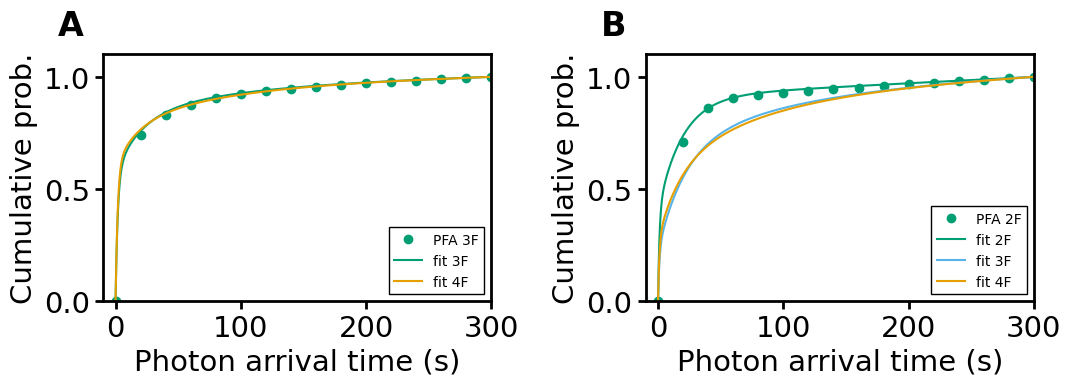

In [ ]:
gs = plt.GridSpec(1, 2)
fig = plt.figure(figsize=(11, 4))


legendargs = dict(
    framealpha=1,
    edgecolor="black",
    fancybox=False,
)
ax1 = fig.add_subplot(gs[0, 0])


fi.universal_figure(
    data=[fingerprint_3F.index[::20000], fingerprint_3F.values[::20000]],
    axes=ax1,
    color=green,
    marker="o",
    linestyle="",
    label="PFA 3F",
)
fi.universal_figure(
    data=[x, cdf_3F(x)],
    color=green,
    label="fit 3F",
    axes=ax1,
)
fi.universal_figure(
    data=[x, cdf_2_3F(x)],
    color=orange,
    label="fit 4F",
    axes=ax1,
    legend=True,
    ylim=[0, 1.1],
    xlim=[-10, 300],
    xlabel="Photon arrival time (s)",
    ylabel="Cumulative prob.",
    legendargs=legendargs,
)

ax2 = fig.add_subplot(gs[0, 1])
fi.universal_figure(
    data=[fingerprint_2F.index[::20000], fingerprint_2F.values[::20000]],
    axes=ax2,
    color=green,
    marker="o",
    linestyle="",
    label="PFA 2F",
)
fi.universal_figure(
    data=[x, cdf_2F(x)],
    color=green,
    label="fit 2F",
    axes=ax2,
)
fi.universal_figure(data=[x, cdf_3_2F(x)], color=sky_blue, label="fit 3F", axes=ax2)
fi.universal_figure(
    data=[x, cdf_2_2F(x)],
    color=orange,
    label="fit 4F",
    axes=ax2,
    legend=True,
    ylim=[0, 1.1],
    xlim=[-10, 300],
    xlabel="Photon arrival time (s)",
    ylabel="Cumulative prob.",
    legendargs=legendargs,
)
axes = fig.get_axes()
for _, (axis, letter) in enumerate(zip(axes, ["A", "B"])):
    axis.text(
        -0.05,
        1.05,
        letter,
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )

fig.tight_layout()

fig.savefig(
    saving_at + r"\2F_3F_parameter_subset.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)

### <a id='toc1_3_2_'></a>[Figure 2](#toc0_)

This figure can be found in 0_5_modeling -> 4f -> 3nm notebook